<a href="https://colab.research.google.com/github/embedded-by-n/embedded-by-n/blob/main/SW_Classification_with_the_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='fuxia'>Supervised Classification with Decision Trees</font>

Decision Trees are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation (scikit-learn documentation).

## Training Data

You will use the 'zoo dataset' to create a decision tree model.

[Zoo dataset](http://archive.ics.uci.edu/ml/datasets/Zoo?ref=datanews.io) -- As described in the dataset information sheet:


In [5]:
# First, download the zoo dataset to a local (temporary) folder
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data

--2026-08-18 07:52:43--  http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘zoo.data’

zoo.data                [ <=>                ]   4.03K  --.-KB/s    in 0s      

2026-08-18 07:52:43 (88.4 MB/s) - ‘zoo.data’ saved [4126]



In [6]:
# You can also download and display the dataset's description:
# This command downloads the relevant file
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.names
# This command displays the file's contents
!cat zoo.names

--2026-08-18 07:52:43--  http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.names
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘zoo.names’

zoo.names               [ <=>                ]   2.53K  --.-KB/s    in 0s      

2026-08-18 07:52:43 (189 MB/s) - ‘zoo.names’ saved [2587]

1. Title: Zoo database

2. Source Information
   -- Creator: Richard Forsyth
   -- Donor: Richard S. Forsyth 
             8 Grosvenor Avenue
             Mapperley Park
             Nottingham NG3 5DX
             0602-621676
   -- Date: 5/15/1990
 
3. Past Usage:
   -- None known other than what is shown in Forsyth's PC/BEAGLE User's Guide.

4. Relevant Information:
   -- A simple database containing 17 Boolean-valued attributes.  The "type"
      attribute appears to be the class attribute.  Here is a brea

## Data Ingestion

Here you'll "ingest" the data by importing it into [pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html):

In [7]:
from IPython.display import display
import pandas as pd

# Because the data file doesn't have header names, we'll list them here
# You can find a description of the data file at http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.names
feature_names = ['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']

# Import the "zoo" dataset
zoo = pd.read_csv('zoo.data', names = feature_names)

# Lets take a peek at the data
zoo.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [8]:
# We'll now import a few useful packages

# Numpy is a linear algebra library,
# useful for common math operations
import numpy as np
# Matplotlib is a common plotting library
import matplotlib.pyplot as plt
# Seaborn is handy for creating beautiful plots
import seaborn as sns; sns.set()

# Feature Extraction

You'll now split up the data into features and labels. We will not do any special pre-processing to generate features, but you are of course welcome to experiment with engineering new features if you have an intuition for how it will improve your model performance.  

In [9]:
features = zoo.loc[:, 'hair':'catsize'] # Omit animal name
labels = zoo.loc[:, 'type']
# We then convert the feature and labels dataframes to
# numpy ndarrays, which can interface with the scikit-learn models
X = features.to_numpy()
y = labels.to_numpy()

In [10]:
# To help familiarize yourself with these matrices,
# have a look at their 'shapes' and understand why they are so.
print('X shape', X.shape)
print('y shape', y.shape)

X shape (101, 16)
y shape (101,)


In [11]:
#  MY EXPLANATION:

#x = features (this means that there are 16 characteristics to describe each animal, and there are 101 animcals in the data set.)

#y = labels: (This means that there is one label that corresponds to each animal.)

# ML Algorithm and Model

The model you will use to create classifications is called a “Decision Tree”. You have likely seen these charted as thought diagrams, and are a popular tool among biologists for species identification. It’s also a powerful machine learning model that’s relatively intuitive which we can use to practice classification in the ML pipeline.

The decision tree model is described in *A visual introduction to machine learning* (parts [I](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/) and [II](http://www.r2d3.us/visual-intro-to-machine-learning-part-2/)) by Stephanie Yee and Tony Chu, 2018.

We also give one example of pseudo-code for training a simple version tree (with binary splits) in:

[A Course in Machine Learning, ch 1., Decision Trees](http://ciml.info/dl/v0_99/ciml-v0_99-ch01.pdf), by Hal Daumé III, 2015

We encourage you to read it carefully and work with peers to understand it’s behavior.

Additional resources: To use the scikit-learn decision tree algorithm, have a look at their [documentation](https://scikit-learn.org/stable/modules/tree.html). A more advanced ensemble of decision trees is called a “random forest”, while we do not cover it in class you are welcome to learn more about this approach. You can find one useful resource visualizing decision trees and generating random forests [here](https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html).

In [12]:
# INITIALIZE YOUR MODEL HERE
from sklearn.tree import DecisionTreeClassifier

# This creates the decision tree classifier and seeds the random_state as 42 which helps us to reproduce the results.
clf = DecisionTreeClassifier(random_state=42)

In [13]:
# MY EXPLANATION:

# The first thing that I did was to split the data into two groups for training and testing.
# I decided to do an 80/20 split on this and I also used random_state=42 so that I would be able to reproduce the same split each time.
# I chose 42 because The Hitchhiker's Guide to the Galaxy is one of my favourite books, where 42 is famously significant, although the actual number chosen for random_state does not matter.
# It actually does not matter which starting number is used, but selecting a 'seed' or starting point in this way by using a parameter allows us to make sure that we are splitting the data into testing and training parts in the exact same way every time.
# This means that we are able to reproduce the results consistently and it also means that we are able to compare the exact same split of data across even different algorithms to compare differences between them and be sure that the data we are using is not changing between the tests.
# Also I used clf = as the name of the classifier as this is quite established good shorthand.

## Quality Metric and Model Tuning

First, let's begin by splitting our data into training and test sets. You can do so using scikit-learn's [`test_train_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function. When setting its parameters, be mindful record your decisions. (You can also create a validation set by using `test_train_split` a second time.)

In [14]:
# SPLIT YOUR DATA INTO TRAIN/TEST SETS HERE

from sklearn.model_selection import train_test_split  # train_test_split is a function that I am importing from scikit-learn which allows me to split up my data into training and testing sets. This means that I am now able to use the train_test_split function in the code below.

X_train, X_test, y_train, y_test = train_test_split(    # The four variables store the training and testing features and labels after the data has been split.
    X,   # The X contains the features of each animal
    y,   # The y contains the correct label of each animal
    test_size=0.2,  # This is the 80/20 dataset split. This means that 80% of the whole dataset will be used for training and 20% (or .20) will be used for testing.
    random_state=42,  # This is the randon_state=42 that I mentioned earlier.
    stratify=y  # This helps keep the proportions of animals similar across the the training and testing datasets.
)

print("Training features:", X_train.shape)   # By using .shape at the end of this print line I am able to see that my data has been split correctly each time.
print("Test features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

Training features: (80, 16)
Test features: (21, 16)
Training labels: (80,)
Test labels: (21,)


In [15]:
# MY EXPLANATION OF THE OUTPUT:

# If you look at the output here, you can now see that there is a match of 16 between the training features and test features, this is the number we are looking for.

### Train your model

Try training your model decision tree model below on the training set.

In [16]:
# TRAIN YOUR MODEL HERE

# this step actually trains the decision tree and it uses the function (.fit) to give the classifier (clf) the training animals features (X_train) and labels (y_train) that I set out in the previous step.

# This lets the model learn rules about the relationship between the features and the correct animal labels, which I will then later be testing for accuracy with our reserved testing dataset of 20%.

clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Evaluate your model

Start by testing out your model's test set accuracy using the DecisionTree's `score` function.

In [17]:
# EVALUATE YOUR MODEL ON TEST SET HERE

# this next section is the first test of the model where we are able to evaluate its accuracy on the test set.

test_accuracy = clf.score(X_test, y_test)  # by giving the x_test and y_test datasets to the .score() we can calculate the accuracy

print("Test accuracy:", test_accuracy)    # this prints out the test result accuracy.
print("Test accuracy percentage:", test_accuracy * 100, "%")  # and this also prints out the test result accuracy as a percentage value by multiplying by 100 and adding a % sign on the end to make is readable easily.

Test accuracy: 1.0
Test accuracy percentage: 100.0 %


In [18]:
# MY EXPLANATION:

# In this result the model actually achieved a test accuracy of 1.0 (100%).
# And although this means that the decision tree correctly identified every
# animal in the test dataset, it is very important to remember that this is just a small sized test and not
# necessarily an indication that this trained clf will be able to 100% accurately identify all the animals in different or new data it is provided.

# This is exactly why we use cross-validation, because cross-validation tests the model across multiple different splits of the dataset
# rather than relying on the result from just one train/test split.
# This is a very important step because it gives us a better idea of how consistently the model performs.

# I will later on demonstrate this cross-validation with the technique of k-fold cross-validation.

## Visualizing your model

A good first way to investigate your model is by visualizing it! We can do so using code similar to that provided by scikit-learn on the documentation page for the DecisionTreeClassifier model.

You may also find their "[Understanding the decision tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py)" useful for understanding your model's behavior.

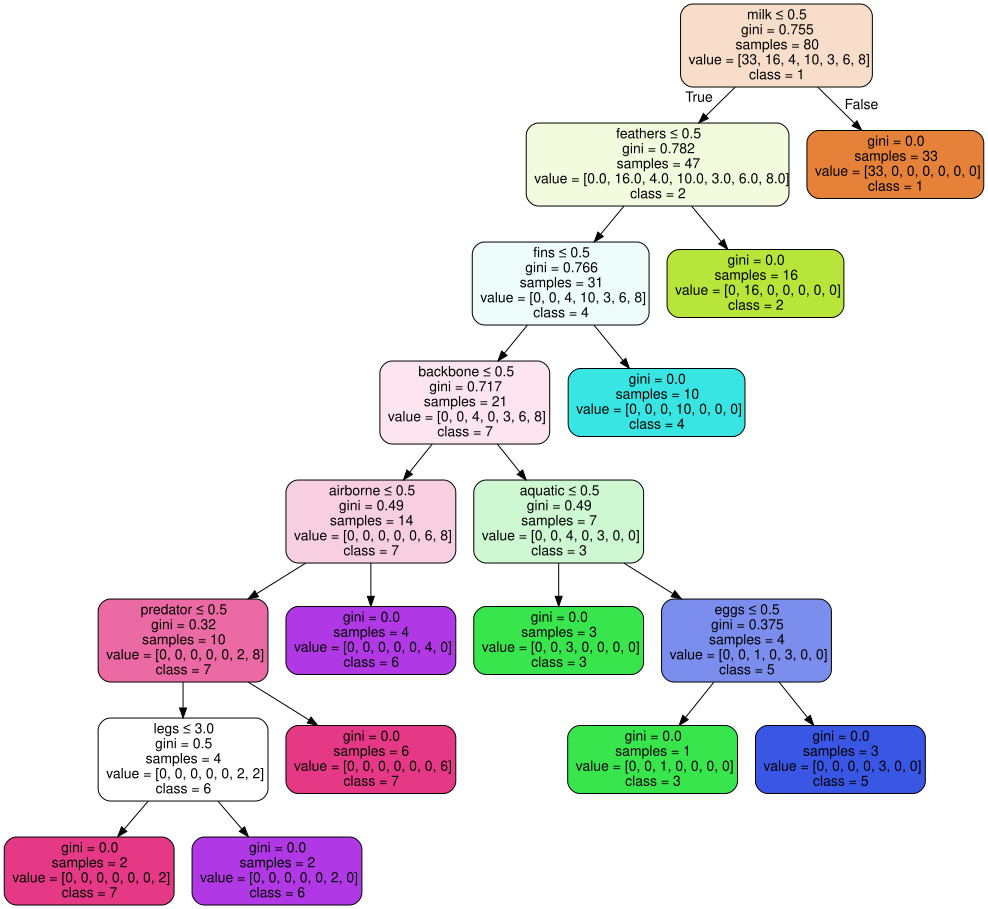

In [19]:
# VISUALIZING YOUR MODEL

from sklearn import tree  # This imports the tree section with tools to visualise the model that I have trained.

import graphviz  # This imports the  Graphviz tool that will actually display the visual diagram.

# I called the followinf variable dot_data because Graphiz actually writes the instructions in a language called DOT.

dot_data = tree.export_graphviz(  # This takes the decision tree that I have trained and exports it into the Graphviz DOT language to be viewed as a diagram.

    clf,

    out_file=None,  # this just means that the exported tree information given back to dot_data rather than being saved into a separate file.

    feature_names=features.columns,  # This makes the actual names of my 16 animal features the columns

    class_names=sorted(list(map(str, labels.unique()))),  # This gets the animal type labels from the dataset and turns them into strings. This it sorts them and uses them as class names on the tree.

    filled=True,  # This tells Graphviz to fill each of the nodes on the decision tree with colours, which also helps to see the different classes that the tree is predicting.

    rounded=True,  # This is really also purely cosmetic but is a fun feature to play with. I makes the tree more visually appealing but it also makes the tree slightly easier to read.

    special_characters=True  # This is also half cosmetic and half with a practical purpose, it helps to visualise special characters such as the (≤) symbol which can make the tree easier to read.
                              # These different visualisation rules are very useful to remember to be able to create graphs that are easier to understand and read for a larger spread of people.
)

graph = graphviz.Source(dot_data)  # This takes the DOT data that I created just above and then uses Graphviz to turn it into the graph below to display.

graph  # This displays the decision tree

In [20]:
# MY EXPLANATION OF THE DECISION TREE OUTPUT:

# The output here is a visual representation of the decision tree that my model learned from the training data.
# The tree is read from the top down from the root node and then follows different branches depending on whether each condition is true or false.
# Each node contains information about the decision being made and the training samples that have reached that point by passing the true of false conditions or the node above that flows into it.

# For example, I can follow one of the actual decisions that my model has learned starting from the very top of the tree.
# The first rule that my model learned concerns milk and is displayed as 'milk <= 0.5'.
# Milk is a Boolean in this dataset, where 0 represents false/no and 1 represents yes/true.
# This means that the threshold of 0.5 effectively separates animals without milk from animals with milk.

# If I follow the branch for the animals with milk, I reach a node containing all 33 of those training samples.
# And this then means that all 33 of these samples belong to class 1, so the node has a gini value of 0.0.

# A gini value of 0.0 means that this node is completely pure because all of the samples at this point belong to the same class.
# This gives me a concrete example of how I can follow the decisions made by the model, which means that there is no black box as every decision is traceable with the tree.

# For example, I can see decisions such as 'feathers <= 0.5', 'fins <= 0.5', 'backbone <= 0.5', 'airborne <= 0.5' in my tree.
# and most of these animal features are represented in the dataset as either 0 or 1, where 0 means false/no and 1 means true/yes.
# This means that when the tree displays something like 'feathers <= 0.5', it is basically separating the animals that do not have feathers, represented by 0, from the animals that do have feathers, represented by 1.

# 'samples' = how many of the training animals have reached that particular node in the decision tree.
# 'value' = how those training animals are distributed across the seven possible animal classes.
# 'class' = which animal class the model would predict for the samples at that particular node.
# 'gini' = how mixed the different animal classes are at that node.

# and as the tree separates the animals into more specific groups, I can see the gini value generally becoming lower as the groups become more pure.
# When I reach a node where gini = 0.0, this means that all of the training samples that reached that node belong to the same animal class.
# E.G. I can see one node in my tree where gini = 0.0, samples = 10 and class = 4.
# This means that all 10 of the training animals that reached this point in the tree belong to class 4.

# I think that this is particularly useful because I can actually inspect the rules that the model has learned and follow the decisions that lead towards a classification, rather than only seeing the final accuracy score.
# This could be particularly helpful in also with much larger datasets, where it is not feasable to manually inspect each piece of information myself.

## Tuning your model

Hyperparameters like max depth can drastically affect your model's performance. Use k-fold cross validation to determine a good `max_depth` for your decision tree. Plot the cross validation score for each `max_depth` setting. Be sure to record how many folds you selected.

You can learn how to do k-fold cross validation with scikit-learn from the [documentation](https://scikit-learn.org/stable/modules/cross_validation.html).

In [21]:
# YOUR CROSS VALIDATION CODE HERE

from sklearn.model_selection import cross_val_score  # This imports the cross_val_score function from scikit-learn which I am going to use to perform k-fold cross-validation.

# The purpose of this next section is to tune the max_depth of my decision tree.
# max_depth controls the maximum number of levels that the decision tree is allowed to grow to.

# If the tree is too shallow it may be too simple to properly learn the patterns in the data, which is called underfitting.
# If the tree is allowed to become unnecessarily complex it can potentially learn patterns that are too specific to the training data, which is called overfitting.

# I also found that max_depth is important for the interpretability of a decision tree.
# Płoński (2020) demonstrates that very deep trees can become difficult to visualise and read, and shows how limiting max_depth can make a tree visualisation more readable.

# This gives me another reason to consider the complexity of my tree rather than only looking for the highest accuracy.
# If a deeper tree does not improve the performance of my model, then the additional complexity may also make the model more difficult to interpret without providing a benefit.


depths = range(1, 11)  # This creates a range of possible max_depth values starting at 1 and finishing at 10, so I can test each of these possible tree depths.

mean_scores = []  # This creates an empty list called mean_scores which I will use to store the average cross-validation accuracy that I get for each of the different max_depth values.


for depth in depths:  # This begins a loop which means that the following process will be repeated for every depth value from 1 through to 10.

    model = DecisionTreeClassifier(  # This creates a new decision tree classifier for the particular depth that is currently being tested in the loop.

        max_depth=depth,  # This sets the maximum depth of this decision tree to the current depth value. This means the loop will first create a tree with max_depth=1, then 2, etc. etc.  and continue until 10.

        random_state=42  # I again use random_state=42 so that the results are reproducible every time.
    )


    scores = cross_val_score(  # This is the line where I actually perform the k-fold cross-validation and store the accuracy results from the different folds in a variable called scores.

        model,  # This tells cross_val_score which decision tree model I want it to test.

        X_train,  # X_train contains the features of the animals in my training dataset.

        y_train,  # y_train contains the correct animal type labels that correspond with the animals in X_train.

        cv=5,  # This is where I have selected 5-fold cross-validation. This means that k = 5 and my training data will be divided into five folds.

        scoring='accuracy'  # This tells cross_val_score that I want to evaluate each model using classification accuracy.
    )


    mean_scores.append(scores.mean())  # The 5-fold cross-validation gives me five accuracy scores. scores.mean() calculates the average of those five scores and append adds this average to my mean_scores list.


    print(  # This prints the results so that I can see the five individual fold scores and their mean for every max_depth that I test.

        f"Depth {depth}: "  # This prints which maximum tree depth is currently being tested.

        f"fold scores = {scores}, "  # This prints the five individual accuracy results that were made by the five folds.

        f"mean = {scores.mean():.3f}"  # This calculates and prints the mean accuracy of the five folds and .3f displays this result to three decimal places (this can be especially handy on larger datasets)
    )

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

Depth 1: fold scores = [0.625  0.5625 0.625  0.625  0.625 ], mean = 0.613
Depth 2: fold scores = [0.75   0.6875 0.75   0.75   0.75  ], mean = 0.738
Depth 3: fold scores = [0.875  0.8125 0.875  0.8125 0.8125], mean = 0.838
Depth 4: fold scores = [0.9375 0.875  0.875  0.875  0.8125], mean = 0.875
Depth 5: fold scores = [1.     0.9375 0.9375 0.875  0.875 ], mean = 0.925
Depth 6: fold scores = [1.     0.9375 0.9375 0.875  0.875 ], mean = 0.925
Depth 7: fold scores = [1.     0.9375 1.     0.9375 0.9375], mean = 0.963
Depth 8: fold scores = [1.     0.9375 1.     0.9375 0.9375], mean = 0.963
Depth 9: fold scores = [1.     0.9375 1.     0.9375 0.9375], mean = 0.963
Depth 10: fold scores = [1.     0.9375 1.     0.9375 0.9375], mean = 0.963


In [22]:
# MY EXPLANATION OF THE 5-FOLD CROSS-VALIDATION:

# The model is trained using four of those folds and then validated using the remaining fold.
# This process is repeated five times so that each of the five folds gets one turn being used as the validation data.
# This gives me five accuracy scores for every max_depth rather than relying on only one validation result.

# I can then take the mean of those five scores so that I have an average cross-validation accuracy that I can use to compare the different max_depth values.
# IMPORTANT NOTE: It is also important that I am doing this using X_train and y_train rather than X_test and y_test because I want to keep my test dataset separate until I have finished tuning my model.

In [23]:
# MY EXPLANATION OF MY CROSS-VALIDATION RESULTS:

# At max_depth=1 my mean cross-validation accuracy is 0.613, or approximately 61.3%.
# At max_depth=2 this increase to approx 73.8%.
# At max_depth=3 increases approx. 83.8%.
# At max_depth=4 87.5%.
# At max_depth=5 and max_depth=6  mean accuracy is 92.5%.
# At max_depth=7 mean accuracy increases to 96.25%.

# The interesting thing is that max_depth 8/9/10 also have exactly the SAME mean cross-validation accuracy of 96.25%.
# This shows me that increasing the complexity of the tree improved the performance at the start but after max_depth=7 the accuracy plateaus.
# This means that it is pointless to allow the tree to grow beyond a max of 7.

# NOTE A LIMITATION:

# One thing I noticed is that the dataset is very small and unevenly distributed between classes.
# Scikit-learn actually warns me that the least populated class in my training data has only three members, which is fewer than my five cross-validation folds.
#  And this means that there are not enough examples from this class to have one  present in every validation fold.
# So although I have demonstrated 5-fold cross-validation, I need to be cautious about interpreting the accuracy of the results.
# This is also a useful reminder that the quality of the evaluation of the model  depends on the technique being used and ALSO on the amount and ALSO the distribution of the data  that is available.

Now that you've completed the ML pipeline for a classifier model Yay!!


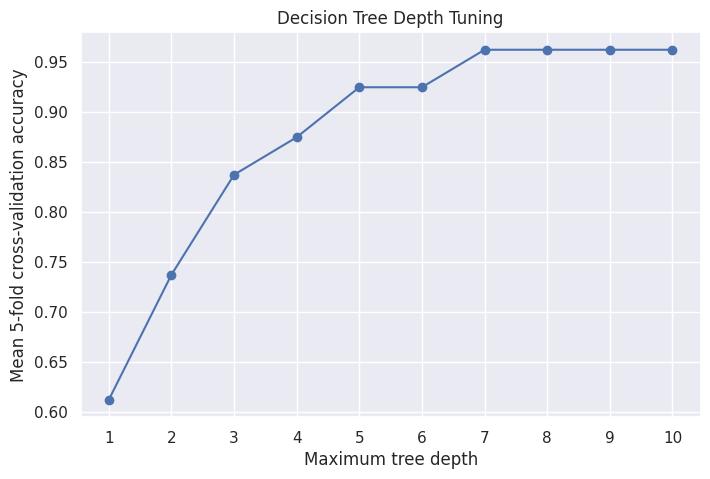

In [24]:
plt.figure(figsize=(8, 5))  # This creates a new figure for my graph and sets its size to 8 units wide by 5 units high so that the graph is large enough to read clearly.

plt.plot(depths, mean_scores, marker='o')  # This plots my tested max_depth values along the x-axis against their mean cross-validation accuracy scores on the y-axis. The marker='o' adds a circle at each tested depth so that I can clearly see each individual result.

plt.xlabel('Maximum tree depth')  # This labels the x-axis as 'Maximum tree depth' because this is the hyperparameter that I have changed from 1 through to 10.

plt.ylabel('Mean 5-fold cross-validation accuracy')  # This labels the y-axis with the mean accuracy produced by my 5-fold cross-validation for each max_depth.

plt.title('Decision Tree Depth Tuning')  # This gives the graph a title which describes what I am using the graph to investigate, which is tuning the depth of my decision tree.

plt.xticks(list(depths))  # This tells the graph to display each of my tested depth values from 1 to 10 as individual values along the x-axis.

plt.grid(True)  # This adds grid lines to the graph which makes it easier for me to visually compare the accuracy scores at the different depths.

plt.show()  # This displays the graph

In [25]:
best_score = max(mean_scores)  # This looks through all of the mean cross-validation scores that I stored earlier and finds the highest score.

best_depth = list(depths)[mean_scores.index(best_score)]  # This finds the position of that highest score in mean_scores and then uses the same position in my depths list to find which max_depth produced it. Because depth 7 is the first depth to achieve the highest score, this selects 7 rather than 8, 9 or 10.

print("Best depth:", best_depth)  # This prints the max_depth that has been selected, which in my results is depth 7.

print("Best mean cross-validation accuracy:", best_score)  # This prints the highest mean cross-validation accuracy, which in my results is 0.9625 or 96.25%.

Best depth: 7
Best mean cross-validation accuracy: 0.9625


In [26]:
# Build the final decision tree using the maximum depth
# selected through cross-validation.

final_clf = DecisionTreeClassifier(  # This creates a new decision tree classifier that will become my final tuned model.

    max_depth=best_depth,  # This sets the maximum depth of the final tree to the best_depth that I selected from my cross-validation results. (which is depth 7.)

    random_state=42  # This again fixes the random state so that the result can be reproduced consistently if I rerun the test.
)


#  Next I will train the final model using all of the training data.

final_clf.fit(X_train, y_train)  # This trains my final tuned decision tree using all of the training features in X_train and their corresponding correct labels in y_train.


# And now I will evaluate it using the test dataset that I held out! :)

final_test_accuracy = final_clf.score(X_test, y_test)  # This evaluates the final tuned model using the test data that I kept separate earlier. This gives me a final accuracy score based on data that was not used to choose the best depth.


print("Selected max depth:", best_depth)  # This prints the maximum depth that was selected through the cross-validation process.

print("Final test accuracy:", final_test_accuracy)  # This prints the final test accuracy as a decimal value.

print("Final test accuracy percentage:", final_test_accuracy * 100, "%")  # This converts the final test accuracy into a percentage so that it is easier to interpret.

Selected max depth: 7
Final test accuracy: 1.0
Final test accuracy percentage: 100.0 %


In [27]:
# MY EXPLANATION:

# My cross-validation process selected a max_depth of 7.
# I then used this depth to build and train my final decision tree classifier.
# The final model was trained using the full training dataset and then evaluated using the held-out test dataset.
# My final test accuracy is 1.0, which is 100%.
# This means that the final tuned model correctly classified all of the animals in this particular test set.
# However, I would not say that the model is simply "100% accurate" overall.
# This test set is quite small, and my mean 5-fold cross-validation accuracy was 96.25%.
# The difference between the 100% final test result and the 96.25% cross-validation result is important because it shows why it is useful to look at more than one evaluation result.
# The cross-validation gives me a better idea of how consistently the model performs across different parts of the training data, while the held-out test set gives me a final check on data that was not used during tuning.

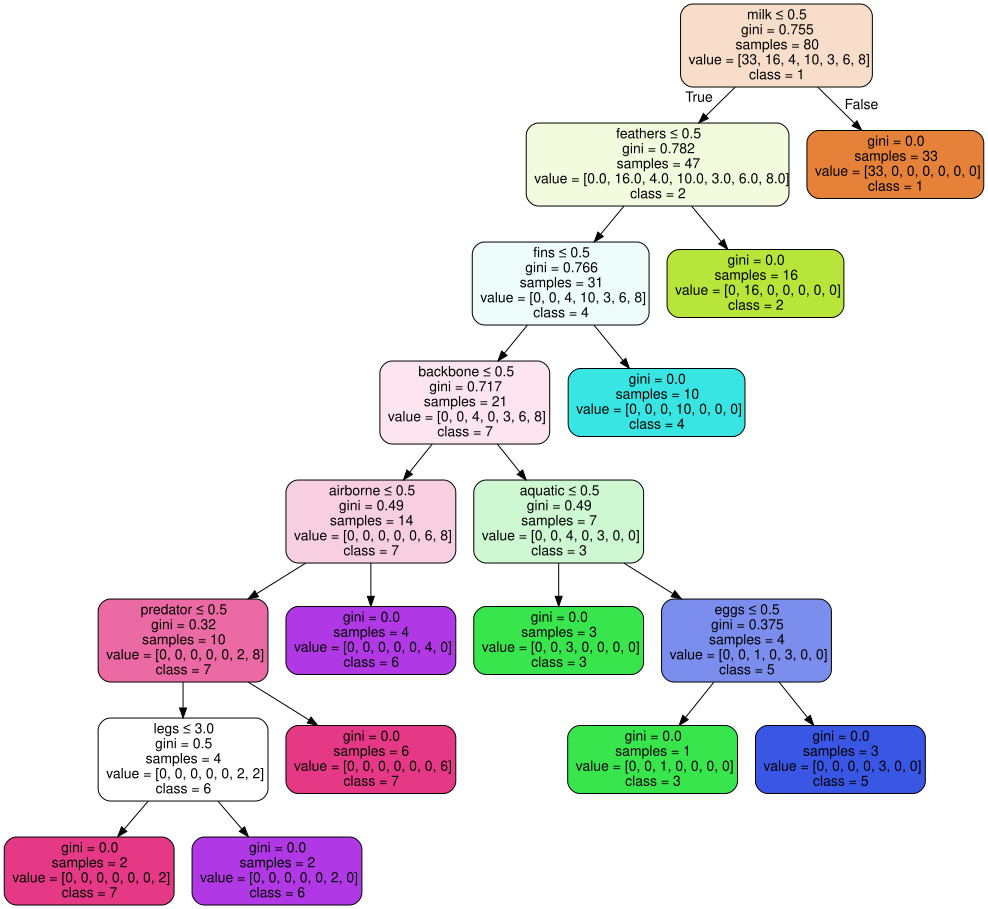

In [28]:
dot_data = tree.export_graphviz(  # This uses tree.export_graphviz again to convert my final trained decision tree into Graphviz data so that I can visualise it.

    final_clf,  # This time I am visualising final_clf, which is my final tuned decision tree with the max_depth that I selected using cross-validation.

    out_file=None,  # This means that the exported Graphviz information is returned and stored in dot_data rather than being saved as a separate file.

    feature_names=features.columns,  # This uses the actual names of my animal features, such as feathers, fins, backbone and legs, when displaying the decisions in the tree.

    class_names=sorted(list(map(str, labels.unique()))),  # This gets the unique animal class labels, converts them into strings, sorts them into order, and uses them as the class names displayed in the tree.

    filled=True,  # This fills the nodes of the tree with colours which makes the different predicted classes easier to distinguish visually.

    rounded=True,  # This gives the nodes rounded corners which makes the visualisation a little easier to read.

    special_characters=True  # This allows special characters, such as the ≤ symbol used in the decision rules, to display correctly.
)


final_graph = graphviz.Source(dot_data)  # This takes the Graphviz data stored in dot_data and converts it into a graph object that can be displayed in my notebook.


final_graph  # This displays the visualisation of my final tuned decision tree.

In [29]:
# COMPARE THE ORIGINAL AND FINAL DECISION TREES

print("ORIGINAL DECISION TREE")  # This creates a heading for the results from my original decision tree.

print("Tree depth:", clf.get_depth())  # This uses get_depth() to show me how deep my original decision tree actually grew.

print("Number of leaves:", clf.get_n_leaves())  # This uses get_n_leaves() to show me how many final leaf nodes the original decision tree contains.

print("Test accuracy:", clf.score(X_test, y_test))  # This shows the accuracy of my original decision tree on the held-out test data.


print("\nFINAL TUNED DECISION TREE")  # This creates a heading for the results from my final decision tree. The \n adds a new line to make the output easier to read.

print("Tree depth:", final_clf.get_depth())  # This shows me the actual depth of my final decision tree after setting max_depth to the value selected through cross-validation.

print("Number of leaves:", final_clf.get_n_leaves())  # This shows me how many final leaf nodes my tuned decision tree contains.

print("Test accuracy:", final_clf.score(X_test, y_test))  # This shows the accuracy of my final tuned decision tree on the same held-out test data.

ORIGINAL DECISION TREE
Tree depth: 7
Number of leaves: 10
Test accuracy: 1.0

FINAL TUNED DECISION TREE
Tree depth: 7
Number of leaves: 10
Test accuracy: 1.0


In [30]:
# MY EXPLANATION OF THE COMPARISON:

# I thought it would be interesting to compare my original decision tree with my final tuned decision tree to see what had actually changed after the tuning process.
# My original decision tree had no max_depth specified, which meant that I had not placed a maximum depth restriction on how far it was allowed to grow.
# Interestingly, when I use get_depth() I can see that my original decision tree naturally stopped growing at a depth of 7 anyway.
# My final tuned decision tree also has a depth of 7 because this was the max_depth that I selected using my 5-fold cross-validation.
# Both trees also contain exactly 10 leaf nodes and both achieve a test accuracy of 1.0, or 100%, on my held-out test dataset.
# This means that in this particular experiment, tuning the max_depth did not actually change the final structure or test accuracy of the decision tree.

# However, this does not mean that the tuning process was unnecessary.
# Before performing the cross-validation, I only knew that my original unrestricted decision tree happened to grow to depth 7 and achieved 100% accuracy on this particular test split.
# The 5-fold cross-validation allowed me to systematically compare max_depth values from 1 through to 10 using different validation folds rather than relying only on that one test result.
# My cross-validation showed that performance improved as max_depth increased until depth 7, where the highest mean cross-validation accuracy of 96.25% was reached.

# Depths 8, 9 and 10 did not improve on this result, which gave me evidence that allowing additional complexity beyond depth 7 was not beneficial for this dataset.
# I find it interesting that the original unrestricted tree naturally arrived at the same depth that my cross-validation process independently selected.


# MY MAIN CONCLUSION FROM THIS COMPARISON:

# The tuning process did not improve my final test accuracy because the original decision tree had already naturally grown to the same depth of 7.
# However, the tuning process gave me evidence that a maximum depth of 7 was a reasonable choice rather than simply assuming that the original model was appropriate.
# Shallower trees performed worse during cross-validation, while allowing maximum depths greater than 7 produced no improvement in mean cross-validation accuracy.
# So even though tuning did not produce a different final tree in this particular experiment, it allowed me to test and justify the complexity of the model.

# There is also an interpretability benefit to avoiding unnecessary tree depth.
# Płoński (2020) demonstrates that very deep decision trees can become difficult to visualise and read.
# In my model, depths 8, 9 and 10 did not improve the mean cross-validation accuracy beyond what I achieved at depth 7.
# This gives me another reason to prefer depth 7: it is the shallowest depth that achieved the highest cross-validation performance, without allowing additional complexity that did not improve the result.

In [31]:
# FINAL REFLECTION:

# this exercise showed me that evaluating a machine-learning model is not just about getting the highest possible accuracy score.
# My first model achieved 100% accuracy on the test set, but that result alone did not tell me how consistently the model would perform on different subsets of the data.

# Cross-validation gave me another way of evaluating the model and also allowed me to systematically test the max_depth hyperparameter.
# In this case, the tuning process selected a maximum depth of 7, which interestingly was also the depth that my original unrestricted tree had naturally reached.
# I therefore did not improve the final test accuracy by tuning max_depth, but I gained evidence that allowing the model to become more complex than depth 7 did not improve its cross-validation performance.

# I would also be cautious about generalising these results because the Zoo dataset is very small and some animal classes contain very few examples.
# For me, one of the useful features of a decision tree is its interpretability. I can not only measure its accuracy, but also inspect the rules and features that it has actually used to make its classifications.

In [33]:
## REFERENCES:

#  Daumé III, H 2015, A course in machine learning, viewed 18 August 2026, https://ciml.info/

#  Forsyth, R 1990, Zoo [dataset], UCI Machine Learning Repository, viewed 18 August 2026, doi:10.24432/C5R59V.

#  Płoński, P 2020, ‘How to visualize a single Decision Tree from the Random Forest in Scikit-Learn (Python)?’, MLJAR, 29 June, viewed 18 August 2026.

#  Yee, S & Chu, T 2015, ‘A visual introduction to machine learning, Part I: A decision tree’, R2D3, viewed 18 August 2026, https://r2d3.us/visual-intro-to-machine-learning-part-1/
